In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

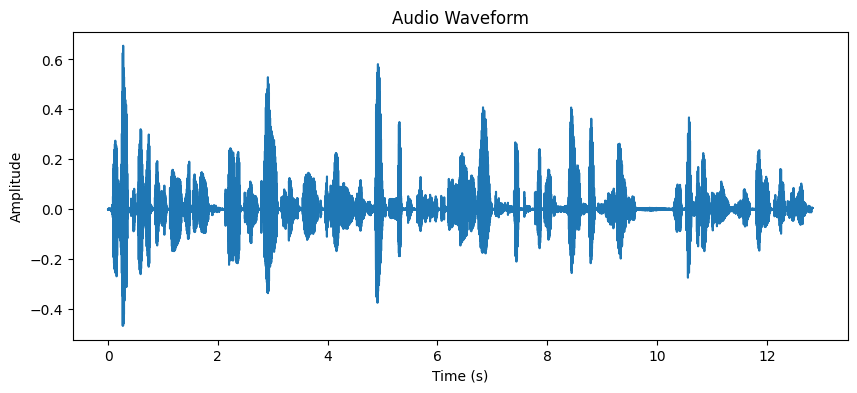

In [169]:
import torch
import numpy as np
import torch.nn.functional as F
from torch import Tensor
# from nanodiarization.utils import play


def play(audio:[Tensor, np.ndarray], sr=44100, autoplay=True):
    from IPython.display import display, Audio
    audio = audio.flatten()
    if audio.dim() > 1 and audio.shape[0] > 1:
        audio = audio.sum(dim=0)[None]
    display(Audio(audio.cpu().detach(), rate=sr, autoplay=autoplay, normalize=False))

import torchaudio

audio, sr = torchaudio.load("/home/harry/storj/data/LibriTTS/test-clean/1089/134686/1089_134686_000001_000001.wav")

play(audio, sr)
import matplotlib.pyplot as plt

# Calculate time values in seconds
time = torch.arange(audio.shape[1]) / sr

plt.figure(figsize=(10, 4))
plt.plot(time, audio.t().numpy())
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Audio Waveform')
plt.show()




In [223]:
def find_nonsilence_chunks(audio, sr, silence_threshold=0.03, min_silence_len=0.25, min_chunk_len=5):
    # Add min_silence_len+1 silence to the end of the audio
    # audio = torch.cat([audio, torch.zeros(1, int(sr*min_silence_len*2)+1)], dim=-1)
    amplitude = torch.abs(audio)
    is_silence = amplitude < silence_threshold
    silent_frames = is_silence.all(dim=0)

    silence_indexes = []
    start_idx = 0

    for idx, is_silent in enumerate(silent_frames):
        if is_silent and start_idx == -1:
            start_idx = idx
        elif not is_silent and start_idx != -1:
            if (idx - start_idx) / sr >= min_silence_len:
                silence_indexes.append((start_idx, idx))
            start_idx = -1

    if start_idx is not None and (len(silent_frames) - start_idx) / sr >= min_silence_len:
        silence_indexes.append((start_idx, len(silent_frames)))

    chunks = []
    cur_chunk = torch.zeros(1, 0)
    cur_idx = 0
    
    for i,(b,e) in enumerate(silence_idxs):
        print(i, b,e)
        if i == len(silence_idxs)-1:
            print("h")
            b += int(sr*.5)

        cur_chunk = torch.cat([cur_chunk, audio[:, cur_idx:b]], dim=-1)
        if cur_chunk.shape[-1] > sr*min_chunk_len:
            cur_idx = e
            chunks.append(cur_chunk)
            cur_chunk = torch.zeros(1, 0)
        else:
            cur_idx = b
    
    # chunks.append(cur_chunk)
    
    return chunks, silence_idxs

for s in find_nonsilence_chunks(audio, sr)[0]:
    play(s, sr)

0 43830 51379
1 170830 177440
2 195149 201316
3 230052 247773
h
tensor([[ 0.0007,  0.0008,  0.0012,  ..., -0.0329, -0.0320, -0.0305]])


tensor([[0.0007, 0.0008, 0.0012,  ..., 0.0406, 0.0407, 0.0369]])


tensor([[0.0420, 0.0714, 0.0392,  ..., 0.0513, 0.0464, 0.0378]])


tensor([[ 0.0420,  0.0714,  0.0392,  ..., -0.0016, -0.0012, -0.0009]])


In [ ]:


chunks, sil_idx = find_nonsilence_chunks(audio, sr)
cur_idx = 0
for b,e in sil_idx:
    play(audio[:, cur_idx:b], sr)
    cur_idx = e

In [142]:
from denoiser import pretrained

In [155]:
play(denoise(audio,sr), 16000)
play(audio,sr)

In [150]:
from torchaudio.transforms import Resample

denoiser =  pretrained.dns64().cpu().eval()

@torch.inference_mode()
def denoise(audio_file, sr=None):
    global denoiser
    if type(audio_file) is str: 
        audio, sr = torchaudio.load(audio_file)
    else:
        audio = audio_file
        assert sr is not None, "You must provide sample rate for preloaded audio"
    
    audio = audio.sum(dim=0, keepdim=True)
    audio = Resample(sr, denoiser.sample_rate)(audio)
    B = 40
    denoiser = denoiser.cuda()
    wav = audio.split(B*denoiser.sample_rate, dim=1)
    denoised = []
    for w in wav:
        denoised.append(denoiser(w.cuda()))
    denoiser = denoiser.cpu()
    denoised = torch.cat(denoised, dim=-1)
    return denoised